<a href="https://colab.research.google.com/github/sejal04-hash/Spaceship-Titanic/blob/main/Spaceship_Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("/content/train.csv")



In [2]:
# Age
# RoomService
# FoodCourt
# ShoppingMall
# Spa
# VRDeck

df["Age"]= df["Age"].fillna(df["Age"].median())
df["RoomService"]= df["RoomService"].fillna(df["RoomService"].median())
df["FoodCourt"]= df["FoodCourt"].fillna(df["FoodCourt"].median())
df["ShoppingMall"]= df["ShoppingMall"].fillna(df["ShoppingMall"].median())
df["Spa"]= df["Spa"].fillna(df["Spa"].median())
df["VRDeck"]= df["VRDeck"].fillna(df["VRDeck"].median())

In [3]:
# HomePlanet
# CryoSleep
# Destination
# VIP
df["HomePlanet"]= df["HomePlanet"].fillna(df["HomePlanet"].mode()[0])
df["CryoSleep"]= df["CryoSleep"].fillna(df["CryoSleep"].mode()[0])
df["Destination"]= df["Destination"].fillna(df["Destination"].mode()[0])
df["VIP"]= df["VIP"].fillna(df["VIP"].mode()[0])


/tmp/ipykernel_3361/3432401445.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["CryoSleep"]= df["CryoSleep"].fillna(df["CryoSleep"].mode()[0])
/tmp/ipykernel_3361/3432401445.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["VIP"]= df["VIP"].fillna(df["VIP"].mode()[0])


In [ ]:
df.isnull().sum()

,0
PassengerId,0
HomePlanet,0
CryoSleep,0
Cabin,199
Destination,0
Age,0
VIP,0
RoomService,0
FoodCourt,0
ShoppingMall,0


In [4]:
# cabine
# B/0/P , F/123/S
# split cabine into deck , number , side

cabine_parts = df['Cabin'].str.split("/",expand = True)
df["cd"]= cabine_parts[0]
df["cn"] = pd.to_numeric(cabine_parts[1],errors = "coerce")
df['cs'] = cabine_parts[2]
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,cd,cn,cs
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,B,0.0,P
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,F,0.0,S
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,A,0.0,S
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,A,0.0,S
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,F,1.0,S


In [5]:
df["cd"]=df["cd"].fillna("Unknown")
df["cs"]=df["cs"].fillna("Unknown")
df['cn']=df['cn'].fillna(df['cn'].median())

In [ ]:
df.isnull().sum()

,0
PassengerId,0
HomePlanet,0
CryoSleep,0
Cabin,199
Destination,0
Age,0
VIP,0
RoomService,0
FoodCourt,0
ShoppingMall,0


In [6]:
df.drop(columns = ['Name','Cabin'],inplace=True)

In [ ]:
df.isnull().sum()

,0
PassengerId,0
HomePlanet,0
CryoSleep,0
Destination,0
Age,0
VIP,0
RoomService,0
FoodCourt,0
ShoppingMall,0
Spa,0


In [7]:
passenger_parts  = df['PassengerId'].str.split('_', expand =True )
df["grpid"] = passenger_parts[0].astype(int)
df['person_number']=passenger_parts[1].astype(int)

In [8]:
grp_size = df['grpid'].value_counts()
df['grp_size'] = df['grpid'].map(grp_size)
print(df[['grp_size','grpid','PassengerId']].head(5))

   grp_size  grpid PassengerId
0         1      1     0001_01
1         1      2     0002_01
2         2      3     0003_01
3         2      3     0003_02
4         1      4     0004_01


In [9]:
print(df["grp_size"].value_counts().sort_index())

grp_size
1    4805
2    1682
3    1020
4     412
5     265
6     174
7     231
8     104
Name: count, dtype: int64


In [ ]:
print(df.groupby('grp_size')['Transported'].mean().sort_index())

grp_size
1    0.452445
2    0.538050
3    0.593137
4    0.640777
5    0.592453
6    0.614943
7    0.541126
8    0.394231
Name: Transported, dtype: float64


In [10]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,cd,cn,cs,grpid,person_number,grp_size
0,0001_01,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,B,0.0,P,1,1,1
1,0002_01,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,F,0.0,S,2,1,1
2,0003_01,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,A,0.0,S,3,1,2
3,0003_02,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,A,0.0,S,3,2,2
4,0004_01,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,F,1.0,S,4,1,1


In [11]:
spending_cols = [
    "RoomService",
    "FoodCourt",
    "ShoppingMall",
    "Spa",
    "VRDeck"
]
df["TotalSpend"] = df[spending_cols].sum(axis=1)

In [ ]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,cd,cn,cs,grpid,person_number,grp_size,TotalSpend
0,0001_01,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,B,0.0,P,1,1,1,0.0
1,0002_01,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,F,0.0,S,2,1,1,736.0
2,0003_01,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,A,0.0,S,3,1,2,10383.0
3,0003_02,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,A,0.0,S,3,2,2,5176.0
4,0004_01,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,F,1.0,S,4,1,1,1091.0


In [12]:
df["ServicesUsed"] = (df[spending_cols] > 0).sum(axis=1)

In [13]:
print(
    df.groupby("ServicesUsed")["Transported"]
    .mean()
)

ServicesUsed
0    0.786477
1    0.346863
2    0.299837
3    0.306576
4    0.269388
5    0.317460
Name: Transported, dtype: float64


In [14]:
print(
    df.groupby("Transported")["TotalSpend"]
    .mean()
)

Transported
False    2004.149247
True      885.689127
Name: TotalSpend, dtype: float64


In [15]:
categorical_cols = [
    "HomePlanet",
    "CryoSleep",
    "Destination",
    "VIP",
    "CabinDeck",
    "CabinSide"
]

In [16]:
numerical_cols = [
    "Age",
    "RoomService",
    "FoodCourt",
    "ShoppingMall",
    "Spa",
    "VRDeck",
    "CabinNumber",
    "PersonNumber",
    "GroupSize",
    "TotalSpend",
    "ServicesUsed"
]

In [ ]:
df.drop(columns=['grpid', 'PassengerId'], inplace=True)

In [17]:
print(df.columns.tolist())

['PassengerId', 'HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported', 'cd', 'cn', 'cs', 'grpid', 'person_number', 'grp_size', 'TotalSpend', 'ServicesUsed']


In [18]:
x = df.drop(columns=['Transported'])
y = df['Transported']

In [19]:
print(x.shape)
print(y.shape)
print(y.value_counts())

(8693, 19)
(8693,)
Transported
True     4378
False    4315
Name: count, dtype: int64


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [24]:
categorical_cols = [
    'HomePlanet',
    'CryoSleep',
    'Destination',
    'VIP',
    'cd',
    'cs'
]

numeric_cols = [
    'Age',
    'RoomService',
    'FoodCourt',
    'ShoppingMall',
    'Spa',
    'VRDeck',
    'cn',
    'person_number',
    'grp_size',
    'TotalSpend',
    'ServicesUsed'
]

In [25]:
X = df[categorical_cols + numeric_cols]
y = df['Transported']

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_val_encoded = preprocessor.transform(X_val)

print(X_train_encoded.shape)
print(X_val_encoded.shape)

(6954, 33)
(1739, 33)


In [28]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_encoded, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

In [29]:

y_pred = model.predict(X_val_encoded)



In [30]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_val, y_pred)

print("Validation Accuracy:", accuracy)

Validation Accuracy: 0.7912593444508338


In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

       False       0.80      0.77      0.79       863
        True       0.78      0.81      0.80       876

    accuracy                           0.79      1739
   macro avg       0.79      0.79      0.79      1739
weighted avg       0.79      0.79      0.79      1739



[[667 196]
 [167 709]]


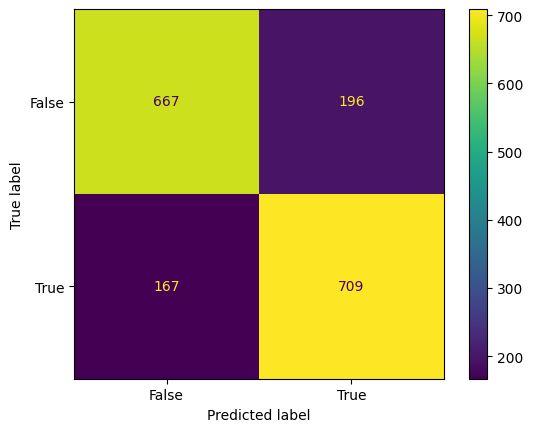

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_pred)

print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["False", "True"]
).plot()

plt.show()

In [33]:
feature_names = preprocessor.get_feature_names_out()

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": model.coef_[0]
})

coef_df["AbsCoefficient"] = coef_df["Coefficient"].abs()

print(
    coef_df
    .sort_values("AbsCoefficient", ascending=False)
    .head(15)
)

                         Feature  Coefficient  AbsCoefficient
1         cat__HomePlanet_Europa     1.097694        1.097694
4            cat__CryoSleep_True     0.856605        0.856605
12                     cat__cd_C     0.606635        0.606635
0          cat__HomePlanet_Earth    -0.589772        0.589772
20                     cat__cs_S     0.507552        0.507552
11                     cat__cd_B     0.450381        0.450381
16                     cat__cd_G    -0.450247        0.450247
5   cat__Destination_55 Cancri e     0.440411        0.440411
3           cat__CryoSleep_False    -0.432900        0.432900
8                 cat__VIP_False     0.410880        0.410880
14                     cat__cd_E    -0.328553        0.328553
13                     cat__cd_D     0.137097        0.137097
32             num__ServicesUsed    -0.122568        0.122568
19                     cat__cs_P    -0.086044        0.086044
2           cat__HomePlanet_Mars    -0.084217        0.084217


In [34]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_encoded, y_train)
rf_pred = rf_model.predict(X_val_encoded)
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_val, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8067855089131685


In [35]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_encoded, y_train)
xgb_pred = xgb_model.predict(X_val_encoded)

from sklearn.metrics import accuracy_score

xgb_accuracy = accuracy_score(y_val, xgb_pred)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.81943645773433


In [37]:
! pip install catboost
from catboost import CatBoostClassifier
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="Accuracy",
    random_seed=42,
    verbose=100
)
cat_model.fit(X_train_encoded, y_train)
cat_pred = cat_model.predict(X_val_encoded)

cat_accuracy = accuracy_score(y_val, cat_pred)

print("CatBoost Accuracy:", cat_accuracy)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00
0:	learn: 0.7677596	total: 52.6ms	remaining: 26.3s
100:	learn: 0.8244176	total: 543ms	remaining: 2.15s
200:	learn: 0.8431119	total: 1.23s	remaining: 1.83s
300:	learn: 0.8613747	total: 2.04s	remaining: 1.35s
400:	learn: 0.8767616	total: 2.77s	remaining: 684ms
499:	learn: 0.8898476	total: 3.54s	remaining: 0us
CatBoost Accuracy: 0.8136860264519838


In [38]:
both_correct = (
    (xgb_pred == y_val.values) &
    (cat_pred == y_val.values)
).sum()

xgb_only = (
    (xgb_pred == y_val.values) &
    (cat_pred != y_val.values)
).sum()

cat_only = (
    (xgb_pred != y_val.values) &
    (cat_pred == y_val.values)
).sum()

both_wrong = (
    (xgb_pred != y_val.values) &
    (cat_pred != y_val.values)
).sum()

print("Both correct:", both_correct)
print("XGBoost only correct:", xgb_only)
print("CatBoost only correct:", cat_only)
print("Both wrong:", both_wrong)

Both correct: 1375
XGBoost only correct: 50
CatBoost only correct: 40
Both wrong: 274


In [40]:
xgb_prob = xgb_model.predict_proba(X_val_encoded)[:, 1]
cat_prob = cat_model.predict_proba(X_val_encoded)[:, 1]

In [41]:
ensemble_prob = (xgb_prob + cat_prob)/2

In [42]:
ensemble_pred = (ensemble_prob >= 0.5).astype(bool)

In [43]:
ensemble_accuracy = accuracy_score(y_val, ensemble_pred)

print("Ensemble Accuracy:", ensemble_accuracy)

Ensemble Accuracy: 0.8188614146060954


In [48]:
ensemble_test= 0.7 * xgb_prob + 0.3 * cat_prob

In [49]:
ensemble_pred = (ensemble_prob >= 0.5).astype(bool)

accuracy = accuracy_score(y_val, ensemble_pred)

print(accuracy)

0.8188614146060954


In [50]:
import pandas as pd

# Load test data
test = pd.read_csv("/content/test.csv")

# ---------- Feature Engineering ----------

# Cabin -> Deck, Number, Side
cabin_parts = test["Cabin"].str.split("/", expand=True)

test["cd"] = cabin_parts[0].fillna("Unknown")
test["cn"] = pd.to_numeric(cabin_parts[1], errors="coerce")
test["cs"] = cabin_parts[2].fillna("Unknown")

# Use TRAIN median for Cabin Number
test["cn"] = test["cn"].fillna(df["cn"].median())

# PassengerId -> Group ID + Person Number
parts = test["PassengerId"].str.split("_", expand=True)
test["grpid"] = parts[0].astype(int)
test["person_number"] = parts[1].astype(int)

# Group size
group_sizes = test["grpid"].value_counts()
test["grp_size"] = test["grpid"].map(group_sizes)

# Spending features
spending_cols = [
    "RoomService",
    "FoodCourt",
    "ShoppingMall",
    "Spa",
    "VRDeck"
]

test["TotalSpend"] = test[spending_cols].sum(axis=1)
test["ServicesUsed"] = (test[spending_cols] > 0).sum(axis=1)

# ---------- Prepare Features ----------

X_test = test[categorical_cols + numeric_cols]

# Encode using the SAME fitted preprocessor
X_test_encoded = preprocessor.transform(X_test)

# ---------- XGBoost Prediction ----------

test_pred = xgb_model.predict(X_test_encoded)

# ---------- Create Submission ----------

submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Transported": test_pred.astype(bool)
})

# Save submission
submission.to_csv("submission_xgboost.csv", index=False)

print("✅ Submission created!")
print(submission.head())
print("\nShape:", submission.shape)
print("\nFile: submission_xgboost.csv")

✅ Submission created!
  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01         True

Shape: (4277, 2)

File: submission_xgboost.csv
